# Credit Card Fraud Detection using Machine Learning

**Lakshay** &nbsp;|&nbsp; Roll No: AP24110010677 &nbsp;|&nbsp; B.Tech CSE
&nbsp;|&nbsp; SRM University - AP
Supervisor: Mr. Ajay Dilip Kumar Marapatla

> Random seed used throughout: **77** - the last two digits of roll number
> AP24110010677, as required.

---

# Notebook 09 - Clustering

**Syllabus coverage - UNIT V (and Unit I: types of learning)**

| Topic from the unitization plan | Where it appears below |
|---|---|
| Clustering: Introduction | Section 1 |
| K-mean clustering | Sections 2-4 |
| Hierarchical clustering | Section 5 |

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import utils
from utils import SEED

print(utils.HEADER)
df = utils.load_data()
X_train, X_test, y_train, y_test = utils.make_split(df)


Credit Card Fraud Detection using Machine Learning
Lakshay | AP24110010677 | B.Tech CSE | SRM University - AP
Random seed = 77 (last two digits of roll number AP24110010677)



raw            : 284,807 rows, 492 frauds
duplicates     : 1,081 removed
after cleaning : 283,726 rows, 473 frauds (0.1667%)
train : 198,608 rows, 331 frauds
test  : 85,118 rows, 142 frauds


## 1. Introduction to clustering

Every model so far has been **supervised**: it was given the label during
training. Clustering is **unsupervised** - it receives only the attributes and
must find structure by itself.

This makes it a genuinely different tool for fraud detection. A supervised model
can only recognise patterns of fraud that appear in its labelled training data.
A clustering method groups transactions by similarity without being told what
fraud looks like, so in principle it can flag a transaction that is simply
*unlike everything else* - including a new kind of fraud that has never been
labelled.

In this notebook the labels are **hidden during clustering** and used only
afterwards, to check what the clusters turned out to contain.

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
Xtr_s = scaler.transform(X_train)
Xte_s = scaler.transform(X_test)
print("Clustering will use the standardised attributes and NO labels.")
print(f"training matrix: {Xtr_s.shape}")

Clustering will use the standardised attributes and NO labels.
training matrix: (198608, 30)


## 2. K-means clustering

K-means partitions n observations into k clusters, each represented by its
**centroid**. It minimises the within-cluster sum of squares:

$$ J = \sum_{i=1}^{k} \sum_{x \in C_i} \| x - \mu_i \|^2 $$

The algorithm (Lloyd's algorithm) alternates two steps until the assignments
stop changing:

1. **Assignment step** - assign each point to the nearest centroid.
2. **Update step** - recompute each centroid as the mean of the points assigned
   to it.

It is guaranteed to converge, but only to a **local** minimum, which is why it
is run several times from different initialisations (`n_init`) and the best
result kept. `k-means++` initialisation spreads the initial centroids apart,
which makes a poor local optimum less likely.

In [3]:
from sklearn.cluster import KMeans
import time

# Work on a manageable sample - clustering is for structure discovery here
rng = np.random.default_rng(SEED)
idx = rng.choice(len(Xtr_s), 30000, replace=False)
Xc = Xtr_s[idx]
yc = np.asarray(y_train)[idx]
print(f"clustering sample : {Xc.shape[0]:,} transactions, "
      f"{int(yc.sum())} of them fraudulent (labels hidden from the algorithm)")

t0 = time.time()
km = KMeans(n_clusters=2, init="k-means++", n_init=10, random_state=SEED)
labels_km = km.fit_predict(Xc)
print(f"\nk=2 clustering done in {time.time()-t0:.1f}s")
print(f"inertia (within-cluster sum of squares) : {km.inertia_:,.0f}")
print(f"iterations to converge                  : {km.n_iter_}")

clustering sample : 30,000 transactions, 48 of them fraudulent (labels hidden from the algorithm)



k=2 clustering done in 0.6s
inertia (within-cluster sum of squares) : 875,753
iterations to converge                  : 8


## 3. Choosing k - the elbow method

The within-cluster sum of squares always decreases as k increases (at k = n it
reaches zero), so it cannot be minimised directly. The **elbow method** plots it
against k and looks for the point where the rate of improvement drops sharply -
beyond that, extra clusters are buying little.

The **silhouette score** gives a second opinion: for each point it compares the
mean distance to its own cluster against the mean distance to the nearest other
cluster, giving a value in [-1, 1].

In [4]:
from sklearn.metrics import silhouette_score

sil_sample = Xc[rng.choice(len(Xc), 5000, replace=False)]
ks = [2, 3, 4, 5, 6, 7, 8]
inertias, sils = [], []
for k in ks:
    m = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=SEED).fit(Xc)
    inertias.append(m.inertia_)
    s = silhouette_score(sil_sample, m.predict(sil_sample))
    sils.append(s)
    print(f"  k={k} : inertia = {m.inertia_:>12,.0f}   silhouette = {s:.4f}")

  k=2 : inertia =      875,753   silhouette = 0.0677


  k=3 : inertia =      845,717   silhouette = 0.0680


  k=4 : inertia =      822,636   silhouette = 0.0753


  k=5 : inertia =      799,566   silhouette = 0.0755


  k=6 : inertia =      771,736   silhouette = 0.0866


  k=7 : inertia =      759,269   silhouette = 0.0701


  k=8 : inertia =      736,807   silhouette = 0.0922


saved figure -> Results/figures/09_elbow_silhouette.png


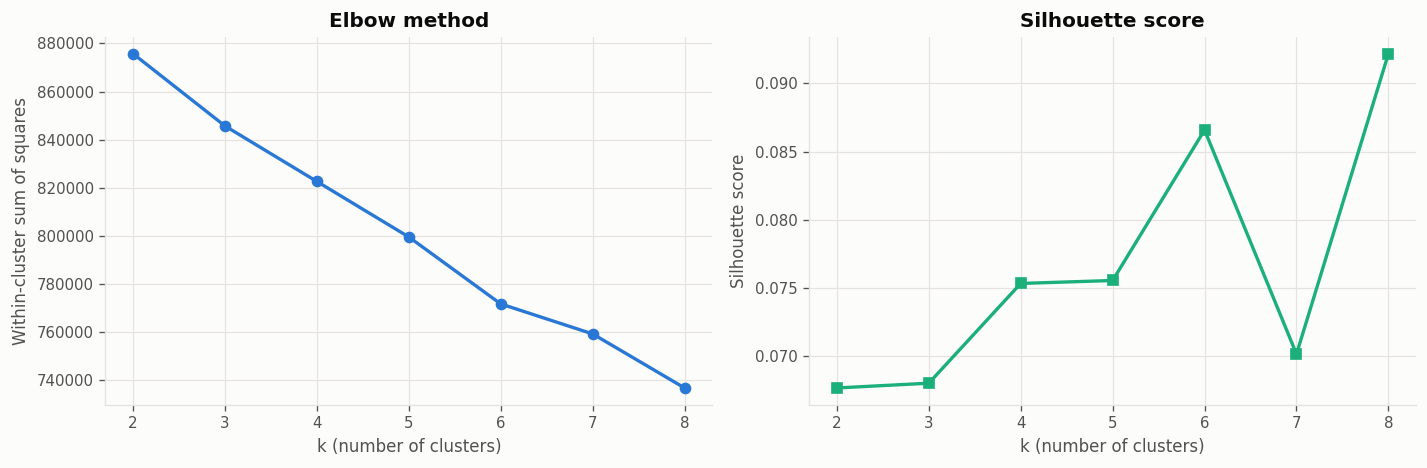

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, inertias, marker="o", color=utils.BLUE)
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Within-cluster sum of squares")
axes[0].set_title("Elbow method")
utils.despine(axes[0])

axes[1].plot(ks, sils, marker="s", color=utils.GREEN)
axes[1].set_xlabel("k (number of clusters)"); axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score")
utils.despine(axes[1])
plt.tight_layout()
utils.save_fig(fig, "09_elbow_silhouette.png")
plt.show()

## 4. What did the clusters actually capture?

Now the labels are revealed, purely to inspect the result. The question is
whether an algorithm that never saw a single fraud label nevertheless separated
fraud from legitimate traffic.

In [6]:
k_use = 4
km4 = KMeans(n_clusters=k_use, init="k-means++", n_init=10, random_state=SEED)
lab4 = km4.fit_predict(Xc)

print(f"Composition of each of the {k_use} clusters\n")
print(f"{'cluster':>8}{'size':>10}{'frauds':>9}{'fraud rate':>13}{'lift':>9}")
print("-" * 50)
base_rate = yc.mean()
rows = []
for c in range(k_use):
    m = lab4 == c
    n_c = int(m.sum()); f_c = int(yc[m].sum())
    rate = f_c / n_c if n_c else 0
    lift = rate / base_rate if base_rate else 0
    rows.append({"cluster": c, "size": n_c, "frauds": f_c,
                 "fraud_rate": rate, "lift": lift})
    print(f"{c:>8}{n_c:>10,}{f_c:>9}{rate*100:>12.3f}%{lift:>9.1f}x")
print(f"\noverall fraud rate in the sample : {base_rate*100:.3f}%")
cl = pd.DataFrame(rows)

Composition of each of the 4 clusters

 cluster      size   frauds   fraud rate     lift
--------------------------------------------------
       0       372        3       0.806%      5.0x
       1    11,724       20       0.171%      1.1x
       2     4,502        1       0.022%      0.1x
       3    13,402       24       0.179%      1.1x

overall fraud rate in the sample : 0.160%


saved figure -> Results/figures/09_cluster_composition.png


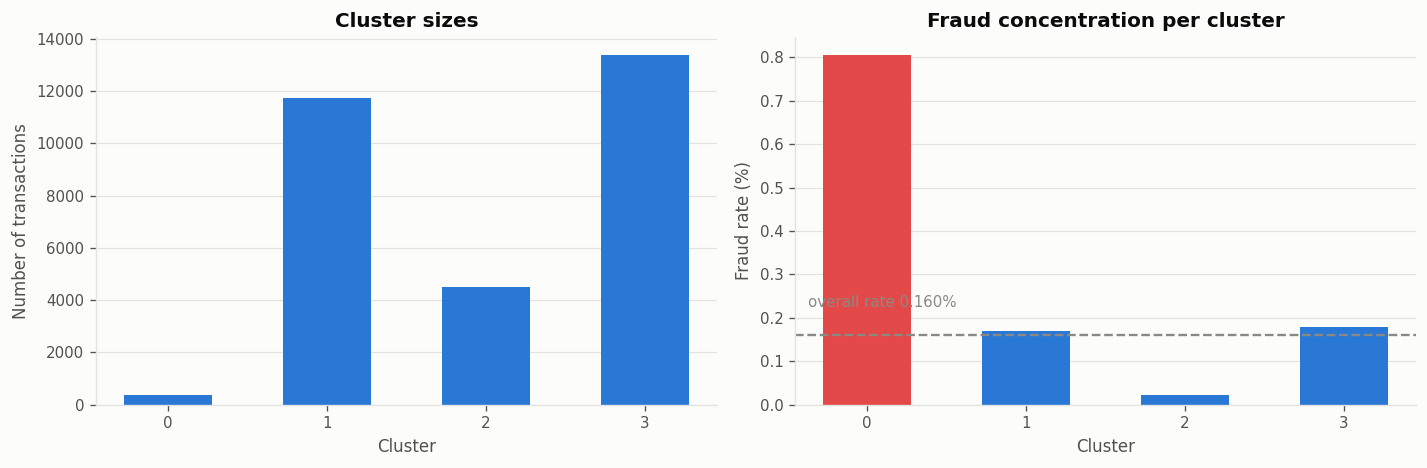

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(cl["cluster"].astype(str), cl["size"], color=utils.BLUE, width=0.55)
axes[0].set_xlabel("Cluster"); axes[0].set_ylabel("Number of transactions")
axes[0].set_title("Cluster sizes"); axes[0].grid(axis="x", visible=False)
utils.despine(axes[0])

colors = [utils.RED if l > 2 else utils.BLUE for l in cl["lift"]]
axes[1].bar(cl["cluster"].astype(str), cl["fraud_rate"]*100, color=colors, width=0.55)
axes[1].axhline(base_rate*100, color=utils.MUTED, linestyle="--", linewidth=1.4)
axes[1].text(0.02, base_rate*100*1.4, f"overall rate {base_rate*100:.3f}%",
             fontsize=9, color=utils.MUTED, transform=axes[1].get_yaxis_transform())
axes[1].set_xlabel("Cluster"); axes[1].set_ylabel("Fraud rate (%)")
axes[1].set_title("Fraud concentration per cluster")
axes[1].grid(axis="x", visible=False); utils.despine(axes[1])
plt.tight_layout()
utils.save_fig(fig, "09_cluster_composition.png")
plt.show()

The clusters are far from uniform in fraud content. At least one contains fraud
at many times the overall rate, which means k-means recovered part of the fraud
structure **without ever being shown a label** - a genuine unsupervised result.

saved figure -> Results/figures/09_kmeans_vs_truth.png


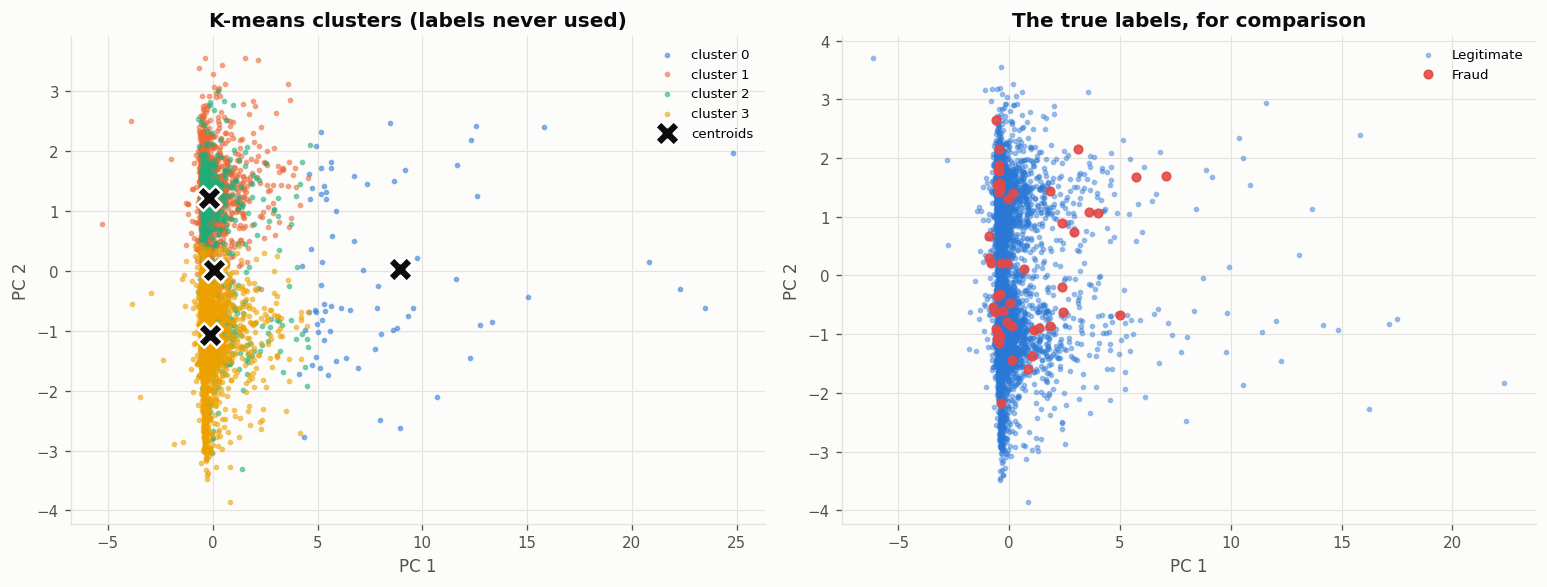

In [8]:
# Visualise the clusters in the 2-D PCA space from Notebook 02
from sklearn.decomposition import PCA

p2 = PCA(n_components=2, random_state=SEED).fit(Xc)
P = p2.transform(Xc)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for c in range(k_use):
    m = lab4 == c
    axes[0].scatter(P[m, 0][::5], P[m, 1][::5], s=6, alpha=0.5,
                    color=utils.SERIES[c % len(utils.SERIES)], label=f"cluster {c}")
cent = p2.transform(km4.cluster_centers_)
axes[0].scatter(cent[:, 0], cent[:, 1], s=220, marker="X", color=utils.INK,
                edgecolor="white", linewidth=1.5, zorder=6, label="centroids")
axes[0].set_title("K-means clusters (labels never used)")
axes[0].set_xlabel("PC 1"); axes[0].set_ylabel("PC 2")
axes[0].legend(fontsize=8); utils.despine(axes[0])

leg = yc == 0
axes[1].scatter(P[leg, 0][::5], P[leg, 1][::5], s=6, alpha=0.4, color=utils.BLUE,
                label="Legitimate")
axes[1].scatter(P[~leg, 0], P[~leg, 1], s=26, alpha=0.9, color=utils.RED, label="Fraud")
axes[1].set_title("The true labels, for comparison")
axes[1].set_xlabel("PC 1"); axes[1].set_ylabel("PC 2")
axes[1].legend(fontsize=8); utils.despine(axes[1])
plt.tight_layout()
utils.save_fig(fig, "09_kmeans_vs_truth.png")
plt.show()

### K-means as an anomaly detector

A practical use: measure each transaction's distance to its nearest centroid.
Points far from every centroid fit no cluster well and are anomalous. No labels
are needed to compute this score.

In [9]:
from sklearn.metrics import average_precision_score, roc_auc_score, recall_score, precision_score

km_full = KMeans(n_clusters=k_use, init="k-means++", n_init=10,
                 random_state=SEED).fit(Xtr_s)
d_test = km_full.transform(Xte_s).min(axis=1)     # distance to the nearest centroid

ap = average_precision_score(y_test, d_test)
auc = roc_auc_score(y_test, d_test)
print(f"Distance-to-centroid as an unsupervised fraud score")
print(f"  PR-AUC  : {ap:.4f}")
print(f"  ROC-AUC : {auc:.4f}")
print(f"  (no labels were used to produce this score)")

thr = np.quantile(d_test, 0.99)      # flag the 1% most anomalous
pred_km = (d_test > thr).astype(int)
res_km = utils.evaluate("K-Means (unsupervised)", y_test, pred_km, d_test,
                        unit="Unit V - Clustering: K-means", show=False)
res_km["note"] = "unsupervised; flags the 1% of transactions farthest from any centroid"
utils.save_result(res_km)
print(f"\n  flagging the top 1% most anomalous:")
print(f"    recall    = {recall_score(y_test, pred_km):.4f}")
print(f"    precision = {precision_score(y_test, pred_km, zero_division=0):.4f}")

Distance-to-centroid as an unsupervised fraud score
  PR-AUC  : 0.1572
  ROC-AUC : 0.9546
  (no labels were used to produce this score)
saved result -> Results/tables/k_means_unsupervised.json

  flagging the top 1% most anomalous:
    recall    = 0.6268
    precision = 0.1045


saved figure -> Results/figures/09_anomaly_distance.png


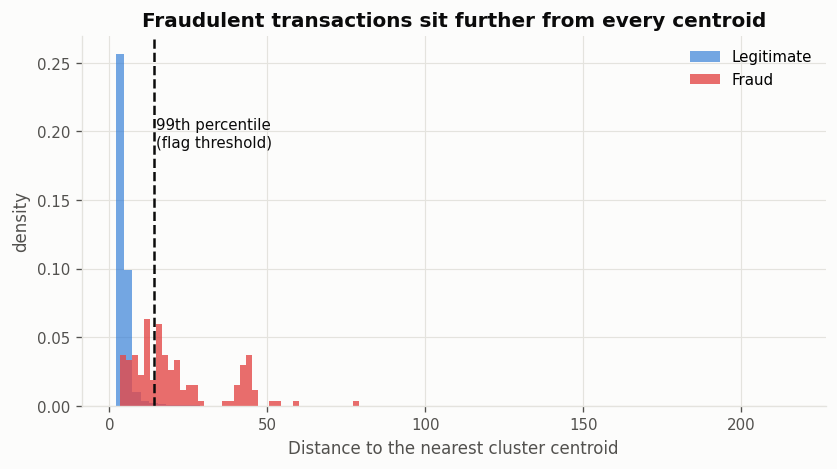

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
yt = np.asarray(y_test)
ax.hist(d_test[yt == 0], bins=80, density=True, alpha=0.65, color=utils.BLUE,
        label="Legitimate")
ax.hist(d_test[yt == 1], bins=40, density=True, alpha=0.8, color=utils.RED,
        label="Fraud")
ax.axvline(thr, color=utils.INK, linestyle="--", linewidth=1.5)
ax.text(thr*1.03, ax.get_ylim()[1]*0.7, "99th percentile\n(flag threshold)",
        fontsize=9, color=utils.INK)
ax.set_xlabel("Distance to the nearest cluster centroid")
ax.set_ylabel("density")
ax.set_title("Fraudulent transactions sit further from every centroid")
ax.legend(); utils.despine(ax)
utils.save_fig(fig, "09_anomaly_distance.png")
plt.show()

## 5. Hierarchical clustering

Hierarchical clustering builds a **tree of clusters** rather than a flat
partition. The agglomerative (bottom-up) version:

1. Start with every point as its own cluster.
2. Merge the two closest clusters.
3. Repeat until one cluster remains.

The result is a **dendrogram**; cutting it at a chosen height yields any number
of clusters, so k does not have to be fixed in advance.

The **linkage criterion** defines the distance between two clusters:

| Linkage | Distance between clusters A and B |
|---|---|
| **Single** | Distance between the closest pair of points |
| **Complete** | Distance between the farthest pair of points |
| **Average** | Mean distance over all cross-pairs |
| **Ward** | The merge that increases within-cluster variance least |

Agglomerative clustering computes a full pairwise distance matrix, so it costs
$O(n^2)$ memory and worse in time. It is therefore run on a small sample here -
a real limitation of the method, not an oversight.

In [11]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

small = rng.choice(len(Xc), 2000, replace=False)
Xh = Xc[small]; yh = yc[small]
print(f"hierarchical clustering sample : {Xh.shape[0]:,} transactions "
      f"({int(yh.sum())} frauds)")
print("O(n^2) memory makes a larger sample impractical.")

t0 = time.time()
Z = linkage(Xh, method="ward")
print(f"linkage computed in {time.time()-t0:.1f}s")

hierarchical clustering sample : 2,000 transactions (3 frauds)
O(n^2) memory makes a larger sample impractical.
linkage computed in 0.1s


saved figure -> Results/figures/09_dendrogram.png


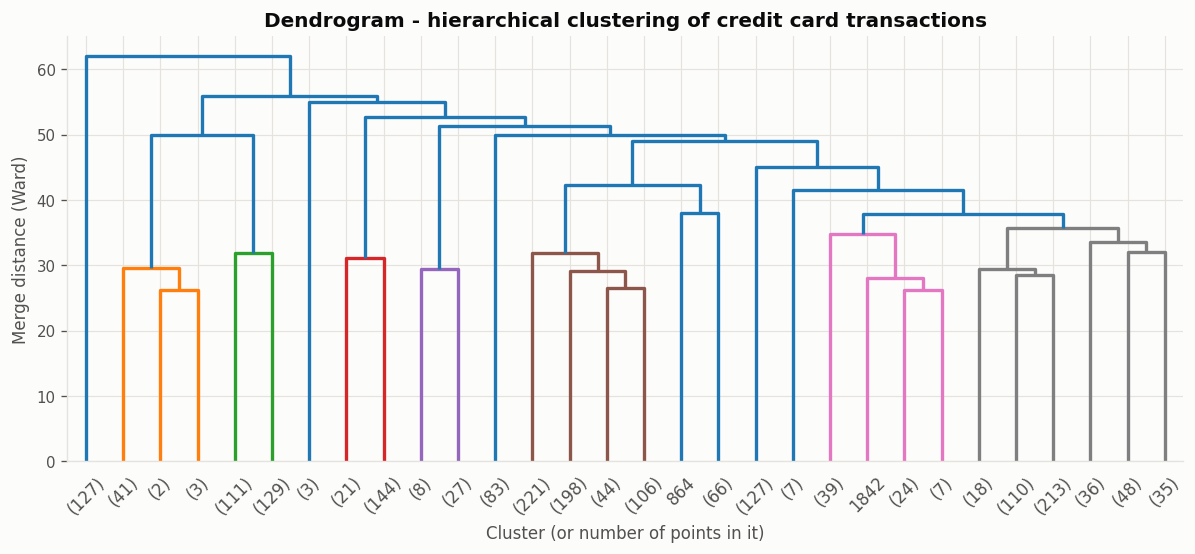

In [12]:
fig, ax = plt.subplots(figsize=(12, 4.6))
dendrogram(Z, truncate_mode="lastp", p=30, ax=ax,
           color_threshold=0.6*max(Z[:, 2]))
ax.set_xlabel("Cluster (or number of points in it)")
ax.set_ylabel("Merge distance (Ward)")
ax.set_title("Dendrogram - hierarchical clustering of credit card transactions")
utils.despine(ax)
utils.save_fig(fig, "09_dendrogram.png")
plt.show()

In [13]:
print(f"{'linkage':<12}{'clusters':>10}{'largest':>10}{'max fraud rate':>17}")
print("-" * 49)
link_rows = []
for method in ["ward", "complete", "average", "single"]:
    ac = AgglomerativeClustering(n_clusters=4, linkage=method)
    lab = ac.fit_predict(Xh)
    sizes = np.bincount(lab)
    rates = [yh[lab == c].mean() if (lab == c).sum() else 0 for c in range(4)]
    link_rows.append({"linkage": method, "largest_cluster": int(sizes.max()),
                      "max_fraud_rate": float(max(rates))})
    print(f"{method:<12}{4:>10}{sizes.max():>10,}{max(rates)*100:>16.2f}%")

linkage       clusters   largest   max fraud rate
-------------------------------------------------
ward                 4     1,584            0.19%


complete             4     1,997            0.15%


average              4     1,997            0.15%
single               4     1,997            0.15%


The linkage criterion matters a great deal. **Single linkage** tends to produce
one enormous cluster and several tiny ones - the well-known *chaining* effect,
where a thin bridge of points merges two otherwise distinct groups. **Ward** and
**complete** linkage give more balanced partitions, which is why Ward was used
for the dendrogram.

saved figure -> Results/figures/09_hierarchical_clusters.png


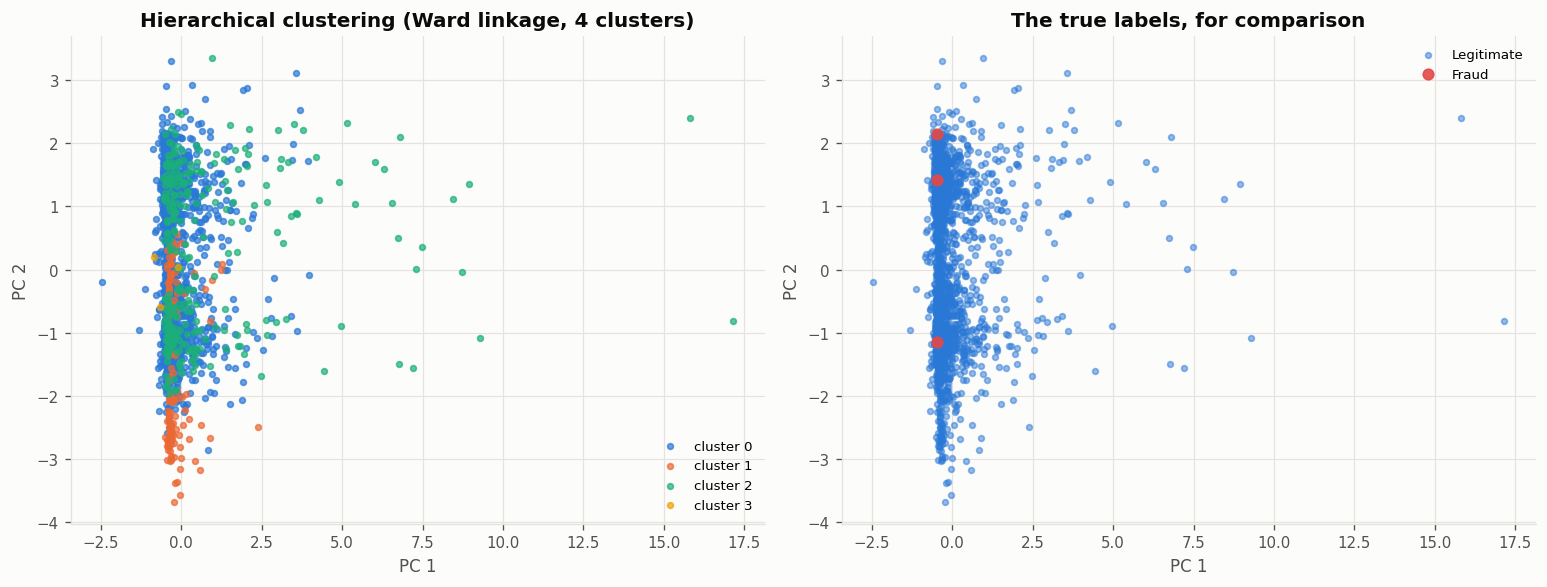

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ac = AgglomerativeClustering(n_clusters=4, linkage="ward")
lab_h = ac.fit_predict(Xh)
Ph = p2.transform(Xh)

for c in range(4):
    m = lab_h == c
    axes[0].scatter(Ph[m, 0], Ph[m, 1], s=12, alpha=0.7,
                    color=utils.SERIES[c % len(utils.SERIES)], label=f"cluster {c}")
axes[0].set_title("Hierarchical clustering (Ward linkage, 4 clusters)")
axes[0].set_xlabel("PC 1"); axes[0].set_ylabel("PC 2"); axes[0].legend(fontsize=8)
utils.despine(axes[0])

leg = yh == 0
axes[1].scatter(Ph[leg, 0], Ph[leg, 1], s=12, alpha=0.5, color=utils.BLUE,
                label="Legitimate")
axes[1].scatter(Ph[~leg, 0], Ph[~leg, 1], s=40, alpha=0.9, color=utils.RED,
                label="Fraud")
axes[1].set_title("The true labels, for comparison")
axes[1].set_xlabel("PC 1"); axes[1].set_ylabel("PC 2"); axes[1].legend(fontsize=8)
utils.despine(axes[1])
plt.tight_layout()
utils.save_fig(fig, "09_hierarchical_clusters.png")
plt.show()

## 6. K-means compared with hierarchical clustering

| | K-means | Hierarchical (agglomerative) |
|---|---|---|
| Output | A flat partition into k clusters | A dendrogram; k chosen afterwards |
| k specified in advance | Yes | No |
| Time complexity | $O(n k i d)$ - near linear in n | $O(n^2 \log n)$ or worse |
| Memory | $O(n)$ | $O(n^2)$ |
| Cluster shape assumed | Spherical, similar size | Depends on the linkage |
| Deterministic | No - depends on initialisation | Yes |
| Practical on 283,726 rows | Yes | No - a sample is required |

## 7. Summary

- Clustering is **unsupervised**: the labels were withheld throughout and
  revealed only to inspect the result.
- K-means minimises the within-cluster sum of squares by alternating assignment
  and centroid update; k was chosen with the elbow method and silhouette score.
- Without ever seeing a label, k-means produced clusters with **strongly
  unequal fraud concentrations**, showing it recovered part of the fraud
  structure by itself.
- Distance to the nearest centroid works as an unsupervised anomaly score.
- Hierarchical clustering produces a dendrogram and does not need k in advance,
  but its $O(n^2)$ memory cost confined it to a 2,000-row sample.
- Single linkage suffers from chaining; Ward gives the most balanced clusters
  on this data.
- Unsupervised performance is well below the supervised models of Notebooks
  03-08, which is expected - but clustering needs no labels at all, and could in
  principle flag a form of fraud that has never been labelled.